# 📊 Skills-Related Underemployment (SRU) by Sex

## Dataset Description
This dataset tracks the number and proportion of **working individuals with tertiary education who are employed in semi-skilled or low-skilled jobs** — a phenomenon known as **skills-related underemployment (SRU)**. Data is quarterly and broken down by **sex**.

This is one of the most direct measures for EduNilai's central question: *"Did the degree pay back?"*

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | Department of Statistics Malaysia (DOSM) |
| **Survey** | Labour Force Survey (LFS), quarterly |
| **Catalogue page** | https://open.dosm.gov.my/data-catalogue/lfs_qtr_sru_sex |
| **Parquet URL** | `https://storage.dosm.gov.my/labour/lfs_qtr_sru_sex.parquet` |
| **License** | CC BY 4.0 |
| **Coverage** | 2016 Q1 – 2023 Q4 |

## Column Descriptions
| Column | Type | Description |
|---|---|---|
| `date` | date | Quarter and year (e.g. 2020-Q1) |
| `sex` | string | `overall`, `male`, or `female` |
| `sru` | integer | Number of tertiary-educated workers in semi/low-skill jobs (thousands) |

## Relevance to EduNilai
This dataset shows how many graduates are working in jobs that don’t require a degree. A high underemployment rate means lower earnings relative to the cost of education, making it a key indicator for assessing degree ROI.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

URL = 'https://storage.dosm.gov.my/labour/lfs_qtr_sru_sex.parquet'
df = pd.read_parquet(URL)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df

,date,variable,sex,sru
0,2017-01-01,rate,overall,29.9
1,2017-04-01,rate,overall,31.8
2,2017-07-01,rate,overall,31.4
3,2017-10-01,rate,overall,32.7
4,2018-01-01,rate,overall,32.5
...,...,...,...,...
205,2024-07-01,persons,female,1063.0
206,2024-10-01,persons,female,1065.5
207,2025-01-01,persons,female,1068.1
208,2025-04-01,persons,female,1072.7


In [7]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDate range:", df['date'].min(), "–", df['date'].max())
if 'sex' in df.columns:
    print("Sex categories:", df['sex'].unique())
print("\nDescriptive stats:")
print(df.describe())

Shape: (210, 4)
Columns: ['date', 'variable', 'sex', 'sru']

Date range: 2017-01-01 00:00:00 – 2025-07-01 00:00:00
Sex categories: ['overall' 'male' 'female']

Descriptive stats:
                                date          sru
count                            210   210.000000
mean   2021-04-01 04:06:51.428571392   586.274286
min              2017-01-01 00:00:00    27.800000
25%              2019-01-01 00:00:00    35.625000
50%              2021-04-01 00:00:00   304.750000
75%              2023-07-01 00:00:00   947.300000
max              2025-07-01 00:00:00  1961.500000
std                              NaN   634.536454


## Data Structure (Before Cleaning)

The dataset is structured in long format, where the `variable` column contains both:

- `sru` → number of underemployed graduates (thousands)

- `sru_rate` → proportion of underemployed graduates (%)

This structure causes plotting issues because both indicators are stored in a single value column.

To properly analyze and visualize the data, we restructure it into a wide format, separating counts and rates into distinct columns.

## Data Structure (After Cleaning)

The dataset has been transformed into wide format, separating the two key indicators:

- `sru_person` → Number of underemployed graduates (thousands)

- `sru_rate` → Underemployment rate (%)

This clean structure allows independent visualization of:

- Absolute labour market mismatch

- Relative underemployment risk

It also prevents plotting errors caused by mixing counts and percentages in a single column

In [20]:
# Inspect structure first
print(df.head())
print(df["variable"].unique())

# Pivot the dataset
df_clean = (
    df.pivot_table(
        index=["date", "sex"],
        columns="variable",
        values="sru",
        aggfunc="first"
    )
    .reset_index()
)

# Rename columns for clarity
df_clean = df_clean.rename(columns={
    "persons": "sru_person",
    "rate": "sru_rate"
})

print(df_clean.head())
print(df_clean.columns)

        date variable      sex   sru
0 2017-01-01     rate  overall  29.9
1 2017-04-01     rate  overall  31.8
2 2017-07-01     rate  overall  31.4
3 2017-10-01     rate  overall  32.7
4 2018-01-01     rate  overall  32.5
['rate' 'persons']
variable       date      sex  sru_person  sru_rate
0        2017-01-01   female       615.9      32.0
1        2017-01-01     male       567.0      27.8
2        2017-01-01  overall      1182.9      29.9
3        2017-04-01   female       695.7      35.3
4        2017-04-01     male       584.9      28.4
Index(['date', 'sex', 'sru_person', 'sru_rate'], dtype='object', name='variable')


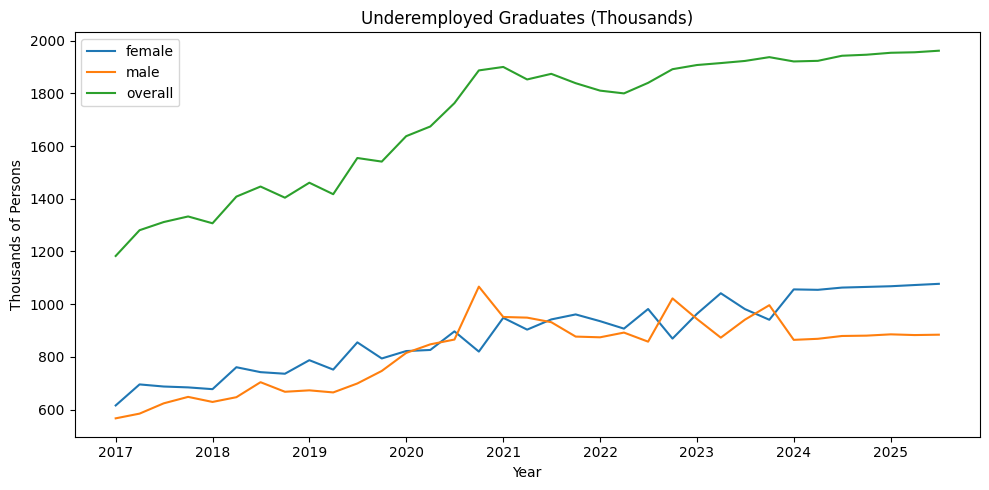

In [21]:
plt.figure(figsize=(10,5))

for sex in df_clean["sex"].unique():
    subset = df_clean[df_clean["sex"] == sex]
    plt.plot(subset["date"], subset["sru_person"], label=sex)

plt.title("Underemployed Graduates (Thousands)")
plt.ylabel("Thousands of Persons")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

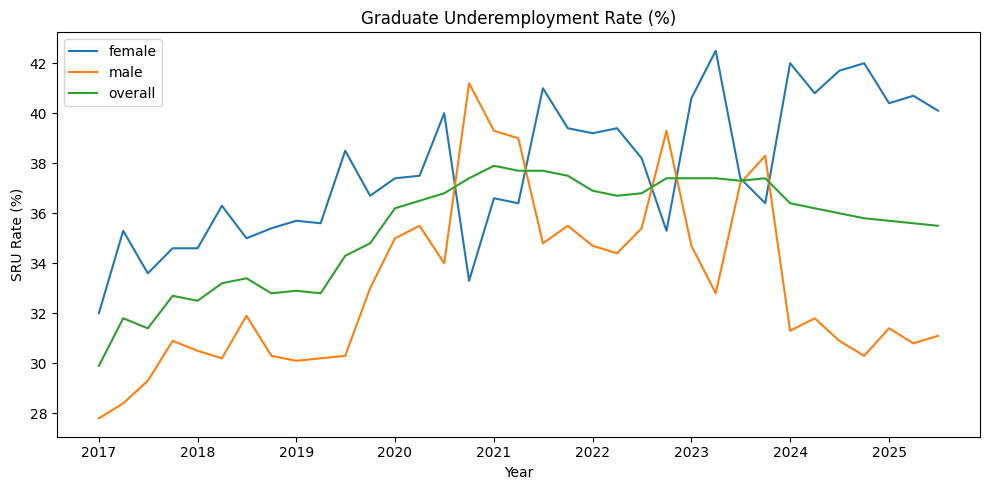

In [22]:
plt.figure(figsize=(10,5))

for sex in df_clean["sex"].unique():
    subset = df_clean[df_clean["sex"] == sex]
    plt.plot(subset["date"], subset["sru_rate"], label=sex)

plt.title("Graduate Underemployment Rate (%)")
plt.ylabel("SRU Rate (%)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
os.makedirs('../data/salary', exist_ok=True)
df.to_csv('../data/salary/graduate_underemployment_sex.csv', index=False, encoding='utf-8')
print("Saved -> ../data/salary/graduate_underemployment_sex.csv")
print(f"Rows exported: {len(df)}")

Saved -> ../data/salary/graduate_underemployment_sex.csv
Rows exported: 210
